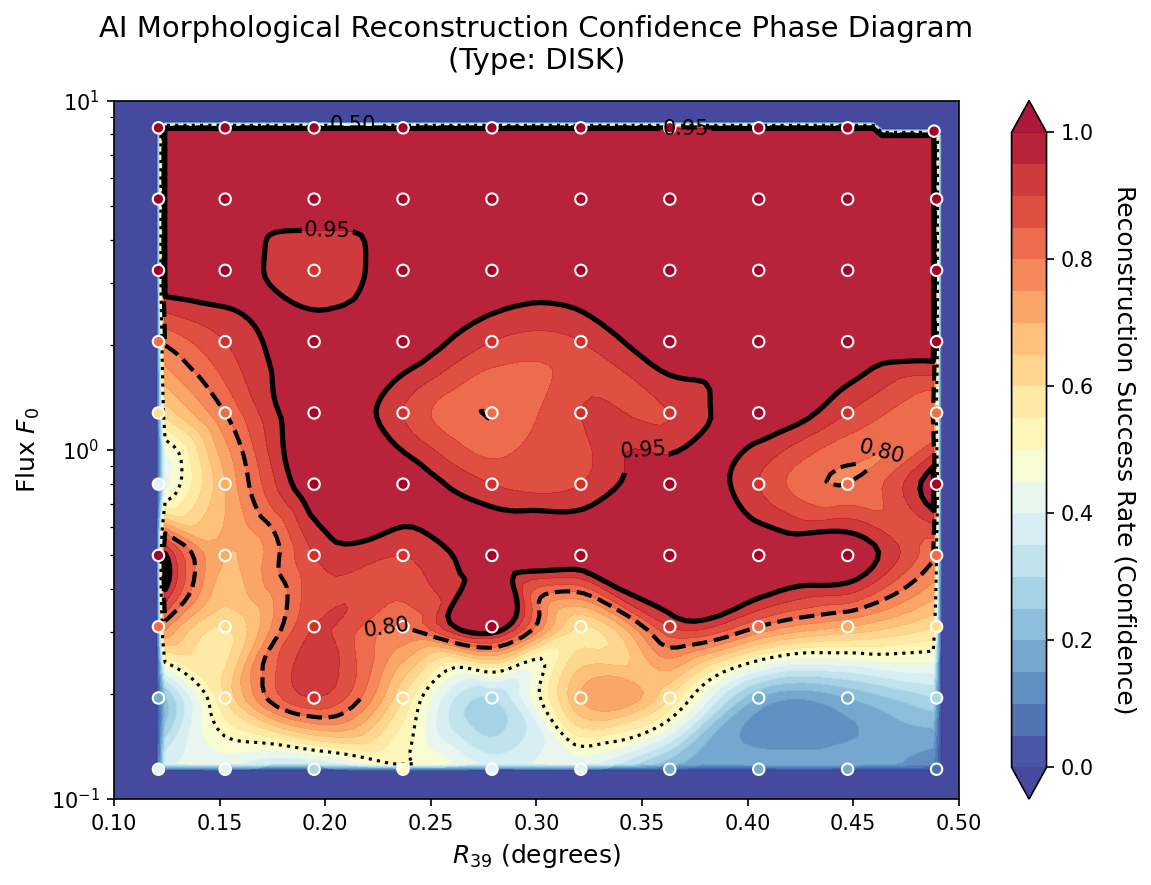

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import griddata

# =========================================
# 1. 图表全局设置 (高阶学术风格)
# =========================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.grid": False,
    "font.family": "sans-serif"
})

# =========================================
# 2. 加载与预处理数据
# =========================================
# 请确保文件路径正确
csv_path = "Exp1_DISK_morphology_per_sample.csv" 
df = pd.read_csv(csv_path)

# 确保 correct 列是布尔型或 0/1 数值
if df['correct'].dtype == object:
    df['correct'] = df['correct'].map({'True': 1, 'False': 0, True: 1, False: 0})
else:
    df['correct'] = df['correct'].astype(int)

# 提取关键列
flux = df['flux_F0'].values
r39 = df['scale_r39_deg'].values
correct = df['correct'].values

# =========================================
# 3. 数据分箱 (Binning)
# =========================================
N_FLUX_BINS = 10
N_R39_BINS = 10

# 对 flux 进行分位数分箱 (尽量保证每个bin样本数相同)
flux_bins = pd.qcut(df['flux_F0'], q=N_FLUX_BINS, retbins=True, duplicates='drop')[1]
# 对 r39 进行等距分箱
r39_bins = np.linspace(0.1, 0.5, N_R39_BINS + 1)

# 将数据映射到 bin 的中心值，方便画连续图
df['flux_bin_center'] = df['flux_F0'].apply(
    lambda x: flux_bins[np.searchsorted(flux_bins, x, side='right') - 1] if x < flux_bins[-1] else flux_bins[-2]
) # 简单取下界，为了更精确，我们下面直接计算 bin 均值

# 更好的中心值映射方法：利用 pandas 的 cut 和 groupby
df['flux_cat'] = pd.qcut(df['flux_F0'], q=N_FLUX_BINS)
df['r39_cat'] = pd.cut(df['scale_r39_deg'], bins=r39_bins)

# 计算每个网格 (flux_bin, r39_bin) 中的：
# 1. 成功率 (mean of correct)
# 2. 该 bin 内真实的 flux 和 r39 的均值 (作为网格中心点)
grouped = df.groupby(['flux_cat', 'r39_cat'], observed=False).agg(
    success_rate=('correct', 'mean'),
    flux_center=('flux_F0', 'mean'),
    r39_center=('scale_r39_deg', 'mean')
).dropna().reset_index()

# =========================================
# 4. 二维插值构建连续曲面
# =========================================
# 提取有效网格点的坐标和值
x_points = grouped['r39_center'].values
y_points = grouped['flux_center'].values  # 注意：稍后我们将对 Y 轴取对数
z_points = grouped['success_rate'].values

# 创建连续的高分辨率网格 (用于平滑插值)
x_grid = np.linspace(r39_bins.min(), r39_bins.max(), 100)
# 由于 flux 是对数分布，我们在对数空间创建 Y 轴网格
y_grid_log = np.linspace(np.log10(flux_bins.min()), np.log10(flux_bins.max()), 100)
y_grid = 10 ** y_grid_log

X, Y = np.meshgrid(x_grid, y_grid)

# 使用 cubic (三次插值) 使相图边界极其平滑
Z = griddata(
    points=(x_points, np.log10(y_points)), # 在对数空间做插值更符合物理规律
    values=z_points, 
    xi=(X, np.log10(Y)), 
    method='cubic', 
    fill_value=0 # 边界外补 0
)

# 防止数值越界
Z = np.clip(Z, 0, 1)

# =========================================
# 5. 绘制连续相图 (Contour Plot)
# =========================================
fig, ax = plt.subplots(figsize=(8, 6))

# 画等高线填充图 (选择一个渐变鲜明的 cmap，如 'RdYlBu_r' 或 'magma')
levels = np.linspace(0, 1.0, 21) # 21 个颜色层级
contour = ax.contourf(X, Y, Z, levels=levels, cmap='RdYlBu_r', extend='both', alpha=0.9)

# 叠加 50%, 80%, 90% 的关键判定边界线
lines = ax.contour(X, Y, Z, levels=[0.5, 0.8, 0.95], colors=['black', 'black', 'black'], 
                   linewidths=[1.5, 2.0, 2.5], linestyles=[':', '--', '-'])
ax.clabel(lines, inline=True, fontsize=10, fmt='%.2f')

# (可选) 叠加上真实的网格采样中心点，展示数据支撑
scatter = ax.scatter(x_points, y_points, c=z_points, cmap='RdYlBu_r', 
                     edgecolors='white', s=30, vmin=0, vmax=1.0, zorder=3)

# 坐标轴设置
ax.set_yscale('log') # Flux 必须是对数轴
ax.set_xlabel(r'$R_{39}$ (degrees)', fontsize=12)
ax.set_ylabel(r'Flux $F_0$', fontsize=12)
ax.set_title('AI Morphological Reconstruction Confidence Phase Diagram\n(Type: DISK)', fontsize=14, pad=15)

# 添加颜色条 (Colorbar)
cbar = fig.colorbar(contour, ax=ax, ticks=[0, 0.2, 0.4, 0.6, 0.8, 1.0])
cbar.set_label('Reconstruction Success Rate (Confidence)', fontsize=12, rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig("Phase_Diagram_DISK.png")
plt.show()